In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
# from scikit_posthocs import posthoc_dunn
# from scipy.stats import f_oneway, kruskal
import scipy.stats as st
# from statannotations.Annotator import Annotator
import statsmodels.api as sm
import matplotlib.colors as mcolors


sns.set_context("notebook", font_scale=1.5)  # Adjust font_scale to increase font size



# Analyse CFU data from community assembly 1
Correlations, rank distributions etc

In [3]:
figure_folder = Path('../../Figures')

## Read in data

In [4]:
data_folder = Path("../../data/1_first_community_assembly")
file_to_open = data_folder / "cfus.csv"
df = pd.read_csv(file_to_open, index_col=0)

In [5]:
wellmap_fn = data_folder / "wellmap.csv"
wellmap_df = pd.read_csv(wellmap_fn, index_col=0)
wellmap_df['Carbon source'] = wellmap_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()
well_to_cs = wellmap_df.set_index('Well').to_dict()['Carbon source']
well_to_rep = wellmap_df.set_index('Well').to_dict()['Replicate']

In [6]:
palette = sns.palettes.color_palette('tab10')
palette = [palette[i] for i in [2,1,0,3]]

In [7]:
strains = ['At', 'Ct', 'Ml', 'Oa']

In [8]:
df['Carbon source'] = df['Carbon source'].str.replace('L-', '').str.replace('D-','')
df = df.loc[df['Carbon source'].notna()]

In [9]:
cs_class_fn = '../../data/4_growth_phenotyping/carbon_sources.csv'
cs_class_df = pd.read_csv(cs_class_fn, index_col=0)
cs_class_df['Carbon source'] = cs_class_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()

cs_to_class = cs_class_df.set_index('Carbon source').to_dict()['Class']
well_to_class = {}
for well, cs in well_to_cs.items():
    if cs == 'No CS':
        well_to_class[well] = 'No CS'
    else:
        try:
            well_to_class[well] = cs_to_class[cs]
        except KeyError:
            well_to_class[well] = 'Mix'

# well_to_cs_type = {well:cs_to_cs_type[cs] for well, cs in cs_class_df.items() if not '+' in cs and not (cs == 'No CS')}

# Read in growth data

In [10]:
folder_monocultures = Path('../../data/4_growth_phenotyping/')

rate_df = pd.read_csv(folder_monocultures / 'fitted_growth_parameters.csv', index_col=0)
rate_df['Carbon source'] = rate_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()
rate_df['# CS'] = 1
rate_df.replace({'max_growth_rate':{np.nan:0}}, inplace=True)



In [11]:
# First, calculate the max growth rate of the carbon source pairs as the sume of the growthr ate on the individuals
double_cs = sorted([x for x in df['Carbon source'].unique() if '+' in x])
double_rates = []
for cs_pair in double_cs:
    cs1, cs2 = cs_pair.split(' + ')
    for strain in strains:
        rate1 = rate_df.loc[(rate_df['Species'] == strain) & (rate_df['Carbon source'] == cs1), 'max_growth_rate'].values[0]
        rate2 = rate_df.loc[(rate_df['Species'] == strain) & (rate_df['Carbon source'] == cs2), 'max_growth_rate'].values[0]
        double_rates.append({'Species': strain, 'Carbon source': cs_pair, 'max_growth_rate': rate1 + rate2})
double_rate_df = pd.DataFrame(double_rates)
double_rate_df['# CS'] = 2
rate_df = pd.concat([rate_df, double_rate_df])

## Compute rank

In [12]:
df_mean78 = df.loc[df.Batch.isin([7,8])].groupby(['Strain', 'Carbon source']).agg({'CFUs/mL':['mean', 'std']}).reset_index()    

# Group by 'Carbon source' and rank species by abundance
df_mean78[('Abundance rank', '')] = df_mean78.groupby([('Carbon source', '')]).rank(ascending=False, method='min')[( 'CFUs/mL', 'mean')]
df_mean78.columns = ['Species', 'Carbon source', 'Mean CFUs/mL', 'Std CFUs/mL', 'Abundance rank']

### Rank from monoculture data

In [13]:
rate_df['Growth rate rank'] = rate_df[['Carbon source','Species','max_growth_rate']].groupby('Carbon source').rank(ascending=False, method='min')['max_growth_rate']

In [14]:
df_mean78 = pd.merge(left = df_mean78, right = rate_df[['Carbon source', 'Growth rate rank', 'Species', 'max_growth_rate', '# CS']], on = ['Carbon source', 'Species'], how = 'left')

In [15]:
df_mean78

,Species,Carbon source,Mean CFUs/mL,Std CFUs/mL,Abundance rank,Growth rate rank,max_growth_rate,# CS
0,At,Acetate,9.333333e+08,3.932768e+08,2.0,3.0,0.095601,1.0
1,At,Acetate + Alanine,1.400000e+09,2.828427e+08,2.0,3.0,0.228739,2.0
2,At,Alanine,3.733333e+09,4.501851e+08,1.0,2.0,0.133138,1.0
3,At,Alanine + Glucose,6.666667e+09,2.927570e+09,1.0,2.0,0.372152,2.0
4,At,Citrate,1.000000e+08,3.651484e+07,4.0,4.0,0.000000,1.0
...,...,...,...,...,...,...,...,...
123,Oa,No CS,8.666667e+02,5.163978e+02,3.0,NaN,NaN,NaN
124,Oa,Ribose,3.760000e+09,8.648699e+08,2.0,1.0,0.103032,1.0
125,Oa,Ribose + Glutarate,1.500000e+08,8.648699e+07,4.0,1.0,0.414995,2.0
126,Oa,Xylose,5.266667e+07,1.573107e+07,2.0,2.0,0.215384,1.0


In [16]:
nanidx = df_mean78['Growth rate rank'].notna()
st.spearmanr(df_mean78.loc[nanidx, 'Growth rate rank'], df_mean78.loc[nanidx, 'Abundance rank'])
st.pearsonr(df_mean78.loc[nanidx, 'Growth rate rank'], df_mean78.loc[nanidx, 'Abundance rank'])

# st.pearsonr(df_mean78.loc[~nanidx, 'Abundance rank'], df_mean78.loc[~nanidx, 'Growth rate rank'])

PearsonRResult(statistic=np.float64(0.3855885298613674), pvalue=np.float64(9.756328193613534e-06))

In [17]:
idx1 = nanidx & (df_mean78['# CS'] == 1)
idx2 = nanidx & (df_mean78['# CS'] == 2)
print(st.spearmanr(df_mean78.loc[idx1, 'Growth rate rank'], df_mean78.loc[idx1, 'Abundance rank']))
print(st.spearmanr(df_mean78.loc[idx2, 'Growth rate rank'], df_mean78.loc[idx2, 'Abundance rank']))


SignificanceResult(statistic=np.float64(0.5000854826103946), pvalue=np.float64(2.581524931889803e-05))
SignificanceResult(statistic=np.float64(0.26666666666666666), pvalue=np.float64(0.039437063761087694))


# Create adjusted abundance rank prediction from growth rate ranks


In [18]:
auxotrophs = ['Oa', 'Ml']
prototrophs = ['At', 'Ct']
for i, cs in enumerate(df_mean78['Carbon source'].unique()):
    df_cs = df_mean78[df_mean78['Carbon source'] == cs].copy()
    df_cs.sort_values('Growth rate rank', inplace=True)
    j=0
    while j<4:
        if df_cs.iloc[j]['Species'] in prototrophs:
            break
        j+=1 
    # if j == 0:
    # print(cs, j)
    
    for k, (idx, row) in enumerate(df_cs.iterrows()):
        if k<j:
            df_mean78.at[idx, 'Predicted rank'] = row['Growth rate rank']+1
        elif k == j:
            df_mean78.at[idx, 'Predicted rank'] = row['Growth rate rank']-j
        else:
            df_mean78.at[idx, 'Predicted rank'] = row['Growth rate rank']

In [19]:
# df_mean78.sort_values(['Carbon source','Predicted rank']).iloc[100:]

# Prepare the data for the linear model
# Ensure there are no missing values in the relevant columns
df_clean = df_mean78.dropna(subset=['Abundance rank', 'Predicted rank', 'Growth rate rank', '# CS'])
for n_cs in [1, 2]:

    idx = df_clean['# CS'] == n_cs
    # Define the independent variables (predictors) and the dependent variable (response)
    X1 = df_clean.loc[idx, 'Predicted rank']  # Predictors
    X2 = df_clean.loc[idx, 'Growth rate rank']  # Predictors
    y = df_clean.loc[idx, 'Abundance rank']  # Response

    # Add a constant to the predictors (for the intercept term)
    X1 = sm.add_constant(X1)
    X2 = sm.add_constant(X2)

    # Fit the linear model
    model1 = sm.OLS(y, X1).fit()
    model2 = sm.OLS(y, X2).fit()

    # Print the summary of the model
    print(f'Predicted rank R2 ({n_cs} cs): {model1.rsquared:.2f}, p-value: {model1.f_pvalue:.2e}')
    print(f'Growth rate rank R2 ({n_cs} cs): {model2.rsquared:.2f}, p-value: {model2.f_pvalue:.2e}')

idx = df_clean['# CS'].isin([1,2])
# Define the independent variables (predictors) and the dependent variable (response)
X1 = df_clean.loc[idx, 'Predicted rank']  # Predictors
X2 = df_clean.loc[idx, 'Growth rate rank']  # Predictors
y = df_clean.loc[idx, 'Abundance rank']  # Response

# Add a constant to the predictors (for the intercept term)
X1 = sm.add_constant(X1)
X2 = sm.add_constant(X2)

# Fit the linear model
model1 = sm.OLS(y, X1).fit()
model2 = sm.OLS(y, X2).fit()

# Print the summary of the model
print(f'Predicted rank R2 (1 and 2 cs): {model1.rsquared:.2f}, p-value: {model1.f_pvalue:.2e}')
print(f'Growth rate rank R2 (1 and 2 cs): {model2.rsquared:.2f}, p-value: {model2.f_pvalue:.2e}')

# print(model1.summary())
# print(model1.pvalues)

Predicted rank R2 (1 cs): 0.33, p-value: 6.07e-07
Growth rate rank R2 (1 cs): 0.25, p-value: 2.60e-05
Predicted rank R2 (2 cs): 0.17, p-value: 1.03e-03
Growth rate rank R2 (2 cs): 0.07, p-value: 3.94e-02
Predicted rank R2 (1 and 2 cs): 0.25, p-value: 4.43e-09
Growth rate rank R2 (1 and 2 cs): 0.15, p-value: 9.76e-06


In [20]:
# df_mean78.sort_values(['Carbon source','Predicted rank']).iloc[100:]
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Compute McFadden's R-squared
def compute_pseudo_r2(model):
    llf = model.llf  # Log-likelihood of the fitted model
    llnull = model.llnull  # Log-likelihood of the null model
    pseudo_r2 = 1 - (llf / llnull)  # McFadden's R-squared
    return pseudo_r2

# Prepare the data for the linear model
# Ensure there are no missing values in the relevant columns
df_clean = df_mean78.dropna(subset=['Abundance rank', 'Predicted rank', 'Growth rate rank', '# CS'])
for n_cs in [1, 2]:

    idx = df_clean['# CS'] == n_cs
    # Define the independent variables (predictors) and the dependent variable (response)
    X1 = df_clean.loc[idx, 'Predicted rank']  # Predictors
    X2 = df_clean.loc[idx, 'Growth rate rank']  # Predictors
    y = df_clean.loc[idx, 'Abundance rank']  # Response


    # Fit the linear model
    model1 = OrderedModel(y, X1).fit()
    model2 = OrderedModel(y, X2).fit()

    print(model1.summary())
    print(model2.summary())
        # Calculate pseudo R-squared for both models
    pseudo_r2_model1 = compute_pseudo_r2(model1)
    pseudo_r2_model2 = compute_pseudo_r2(model2)

    # Print the results
    print(f"McFadden's R-squared for Predicted Rank: {pseudo_r2_model1:.4f}")
    print(f"McFadden's R-squared for Growth Rate Rank: {pseudo_r2_model2:.4f}")
    # # Print the summary of the model
    # print(f'Predicted rank R2 ({n_cs} cs): {model1.rsquared:.2f}, p-value: {model1.f_pvalue:.2e}')
    # print(f'Growth rate rank R2 ({n_cs} cs): {model2.rsquared:.2f}, p-value: {model2.f_pvalue:.2e}')

idx = df_clean['# CS'].isin([1,2])
# Define the independent variables (predictors) and the dependent variable (response)
X1 = df_clean.loc[idx, 'Predicted rank']  # Predictors
X2 = df_clean.loc[idx, 'Growth rate rank']  # Predictors
y = df_clean.loc[idx, 'Abundance rank']  # Response

# Fit the linear model
model1 = OrderedModel(y, X1, distr='logit').fit()
model2 = OrderedModel(y, X2, distr='logit').fit()

# Print the summary of the model
print(model1.summary())
# print(f'Predicted rank R2 (1 and 2 cs): {model1.rsquared:.2f}, p-value: {model1.f_pvalue:.2e}')
# print(f'Growth rate rank R2 (1 and 2 cs): {model2.rsquared:.2f}, p-value: {model2.f_pvalue:.2e}')

# print(model1.summary())
# print(model1.pvalues)


# Calculate pseudo R-squared for both models
pseudo_r2_model1 = compute_pseudo_r2(model1)
pseudo_r2_model2 = compute_pseudo_r2(model2)

# Print the results
print(f"McFadden's R-squared for Predicted Rank: {pseudo_r2_model1:.4f}")
print(f"McFadden's R-squared for Growth Rate Rank: {pseudo_r2_model2:.4f}")

Optimization terminated successfully.
         Current function value: 1.180682
         Iterations: 144
         Function evaluations: 241
Optimization terminated successfully.
         Current function value: 1.240549
         Iterations: 123
         Function evaluations: 206
                             OrderedModel Results                             
Dep. Variable:         Abundance rank   Log-Likelihood:                -75.564
Model:                   OrderedModel   AIC:                             159.1
Method:            Maximum Likelihood   BIC:                             167.8
Date:                Thu, 27 Mar 2025                                         
Time:                        15:09:15                                         
No. Observations:                  64                                         
Df Residuals:                      60                                         
Df Model:                           1                                         
         

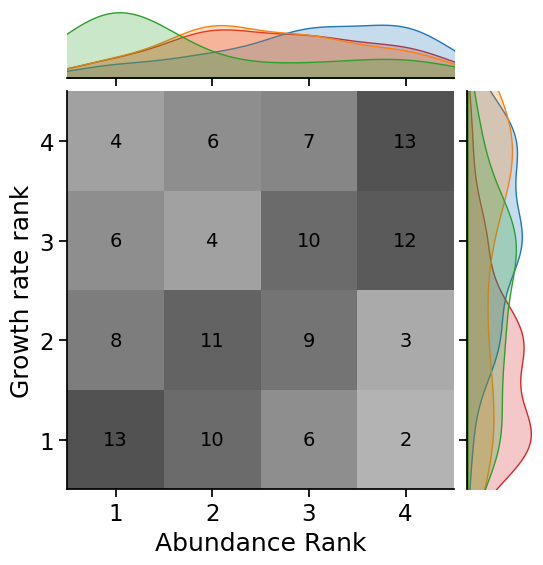

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


species_list = ['At', 'Ct', 'Ml', 'Oa']
# Define a discrete colormap
cmap = mcolors.ListedColormap(sns.color_palette("viridis", n_colors=4).as_hex())
norm = mcolors.BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5], ncolors=4)

# Loop through each species and create a jointplot

idx = df_mean78['# CS'].isin([1,2])
# Create a jointplot for the current species
g = sns.JointGrid(
    data=df_mean78.loc[idx],
    x='Abundance rank',
    y='Growth rate rank',
    # kind='hist',  # Use KDE for the main plot
    # marginal_kws={'common_norm': False, 'fill': True},  # Density plots on the margins
    # bins=4,
    # height=6,
    # ratio=5

    # dropna=True,
    # discrete=(True, True),
    
    # fill=True,  # Fill the KDE plot
    # color = palette[i],
    # cmap = cmap,
    # cbar=True,  # Add
    # thresh=None,
    # cbar_kws=dict(shrink=.75)
    # cmap='viridis'  # Choose a colormap
)
g.plot_joint(sns.histplot, discrete=(True, True), bins = 4, color = 'gray')  
g.plot_marginals(sns.kdeplot, palette=palette, fill=True, hue='Species', hue_order=species_list,data=df_mean78.loc[idx], common_grid=True, common_norm=False)

    # Add a regression line to the main axes
# sns.regplot(
#     data=species_data,
#     x='Abundance rank',
#     y='Growth rate rank',
#     scatter=False,  # Do not show scatter points (to avoid overlap with KDE)
#     ax=g.ax_joint,
#     color='black',  # Color of the regression line
#     line_kws={'linewidth': 2}  # Customize the regression line
# )
g.ax_joint.set_xlim(0.5, 4.5)
g.ax_joint.set_ylim(0.5, 4.5)
g.ax_joint.set_yticks([1, 2, 3, 4])  # Force y-axis ticks to be 1, 2, 3, 4

# Customize the plot
g.ax_joint.set_xlabel('Abundance Rank')
g.ax_joint.set_ylabel('Growth rate rank')

    # g.ax_joint.set_title(f'Jointplot: {species}')
    # Annotate each square with the count
hist_data, x_edges, y_edges = np.histogram2d(
    df_mean78.loc[idx, 'Abundance rank'],
    df_mean78.loc[idx, 'Growth rate rank'],
    bins=4
)

# Loop through the bins and annotate
for i in range(len(x_edges) - 1):
    for j in range(len(y_edges) - 1):
        # Compute the center of each bin
        x = (x_edges[i] + x_edges[i + 1]) / 2
        y = (y_edges[j] + y_edges[j + 1]) / 2
        count = int(hist_data[i, j])
        if count > 0:  # Only annotate non-empty bins
            g.ax_joint.text(i+1, j+1, count, ha='center', va='center', fontsize=14, color='black', fontdict={'weight': 'regular'})

plt.savefig(figure_folder / 'growth_rate_rank_vs_abundance_rank.pdf')



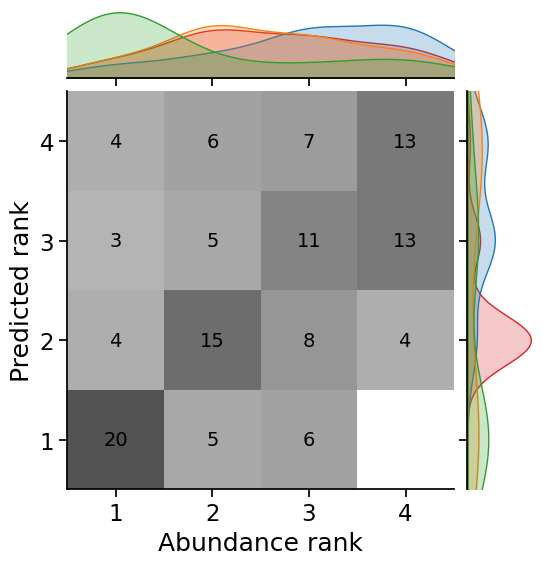

In [22]:



species_list = ['At', 'Ct', 'Ml', 'Oa']
# Define a discrete colormap
cmap = mcolors.ListedColormap(sns.color_palette("viridis", n_colors=4).as_hex())
norm = mcolors.BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5], ncolors=4)

# Loop through each species and create a jointplot

idx = df_mean78['# CS'].isin([1,2])
# Create a jointplot for the current species
g = sns.JointGrid(
    data=df_mean78.loc[idx],
    x='Abundance rank',
    y='Predicted rank',
    # kind='hist',  # Use KDE for the main plot
    # marginal_kws={'common_norm': False, 'fill': True},  # Density plots on the margins
    # bins=4,
    # height=6,
    # ratio=5

    # dropna=True,
    # discrete=(True, True),
    
    # fill=True,  # Fill the KDE plot
    # color = palette[i],
    # cmap = cmap,
    # cbar=True,  # Add
    # thresh=None,
    # cbar_kws=dict(shrink=.75)
    # cmap='viridis'  # Choose a colormap
)
g.plot_joint(sns.histplot, discrete=(True, True), bins = 4, color = 'gray')  
g.plot_marginals(sns.kdeplot, palette=palette, fill=True, hue='Species', hue_order=species_list,data=df_mean78.loc[idx], common_grid=True, common_norm=False)

    # Add a regression line to the main axes
# sns.regplot(
#     data=species_data,
#     x='Abundance rank',
#     y='Growth rate rank',
#     scatter=False,  # Do not show scatter points (to avoid overlap with KDE)
#     ax=g.ax_joint,
#     color='black',  # Color of the regression line
#     line_kws={'linewidth': 2}  # Customize the regression line
# )
g.ax_joint.set_xlim(0.5, 4.5)
g.ax_joint.set_ylim(0.5, 4.5)
g.ax_joint.set_yticks([1, 2, 3, 4])  # Force y-axis ticks to be 1, 2, 3, 4

# Customize the plot
g.ax_joint.set_xlabel('Abundance rank')
g.ax_joint.set_ylabel('Predicted rank')
    # g.ax_joint.set_title(f'Jointplot: {species}')
    # Annotate each square with the count
hist_data, x_edges, y_edges = np.histogram2d(
    df_mean78.loc[idx, 'Abundance rank'],
    df_mean78.loc[idx, 'Predicted rank'],
    bins=4
)

# Loop through the bins and annotate
for i in range(len(x_edges) - 1):
    for j in range(len(y_edges) - 1):
        # Compute the center of each bin
        x = (x_edges[i] + x_edges[i + 1]) / 2
        y = (y_edges[j] + y_edges[j + 1]) / 2
        count = int(hist_data[i, j])
        if count > 0:  # Only annotate non-empty bins
            g.ax_joint.text(i+1, j+1, count, ha='center', va='center', fontsize=14, color='black', fontdict={'weight': 'regular'})

plt.savefig(figure_folder / 'predicted_rank_vs_abundance_rank.pdf')


In [23]:
correct_pred = (df_mean78.loc[idx, 'Predicted rank'] == df_mean78.loc[idx, 'Abundance rank']).sum()
correct_growth = (df_mean78.loc[idx, 'Growth rate rank'] == df_mean78.loc[idx, 'Abundance rank']).sum()
total = len(df_mean78.loc[idx])
print(f'Correctly predicted: {correct_pred}/{total} ({correct_pred/total:.2f})')
print(f'Correctly growth: {correct_growth}/{total} ({correct_growth/total:.2f})')

mad_pred = (df_mean78.loc[idx, 'Predicted rank'] - df_mean78.loc[idx, 'Abundance rank']).abs().sum()/total
mad_growth = (df_mean78.loc[idx, 'Growth rate rank'] - df_mean78.loc[idx, 'Abundance rank']).abs().sum()/total
print(f'MAD predicted: {mad_pred:.2f}')
print(f'MAD growth: {mad_growth:.2f}')

Correctly predicted: 59/124 (0.48)
Correctly growth: 47/124 (0.38)
MAD predicted: 0.74
MAD growth: 0.89


In [24]:
for abundance_rank in [1,2,3,4]:
    idx = (df_mean78['# CS'].isin([1,2])) & (df_mean78['Abundance rank'] == abundance_rank)
    correct_pred = (df_mean78.loc[idx, 'Predicted rank'] == df_mean78.loc[idx, 'Abundance rank']).sum()
    total = len(df_mean78.loc[idx])
    print(f'Correctly predicted ({abundance_rank}): {correct_pred}/{total} ({correct_pred/total:.2f})')

Correctly predicted (1): 20/31 (0.65)
Correctly predicted (2): 15/31 (0.48)
Correctly predicted (3): 11/32 (0.34)
Correctly predicted (4): 13/30 (0.43)


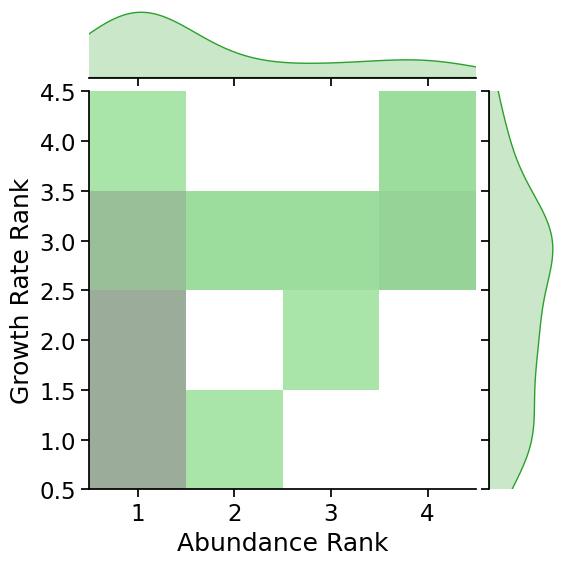

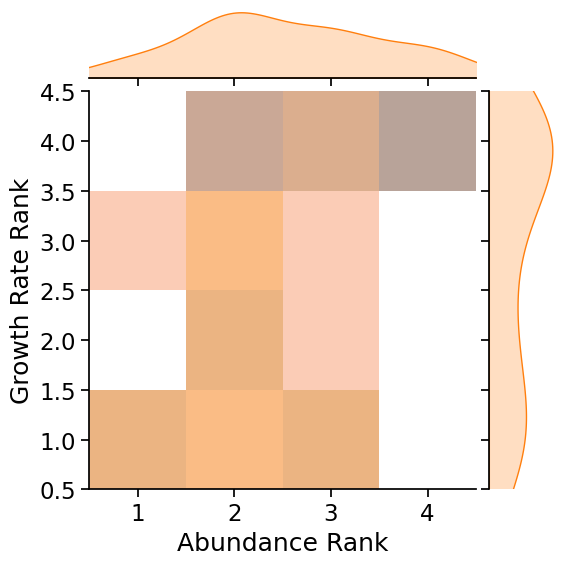

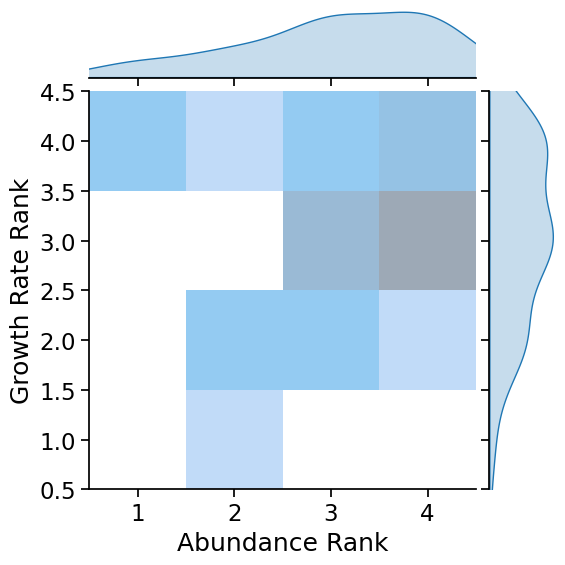

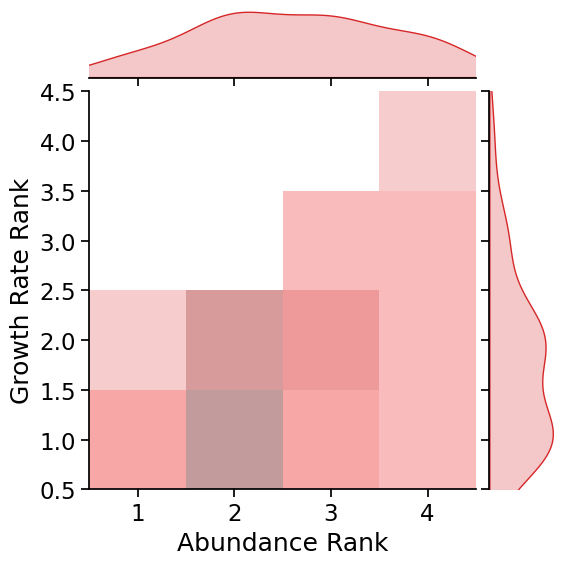

In [25]:


species_list = ['At', 'Ct', 'Ml', 'Oa']
# Define a discrete colormap
cmap = mcolors.ListedColormap(sns.color_palette("viridis", n_colors=4).as_hex())
norm = mcolors.BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5], ncolors=4)

# Loop through each species and create a jointplot
for i, s in enumerate(species_list):
    # Filter the data for the current species
    species_data = df_mean78[df_mean78['Species'] == s]
    
    # Create a jointplot for the current species
    g = sns.JointGrid(
        data=species_data,
        x='Abundance rank',
        y='Growth rate rank',
        # kind='hist',  # Use KDE for the main plot
        # marginal_kws={'common_norm': False, 'fill': True},  # Density plots on the margins
        # bins=4,
        # height=6,
        # ratio=5

        # dropna=True,
        # discrete=(True, True),
        
        # fill=True,  # Fill the KDE plot
        # color = palette[i],
        # cmap = cmap,
        # cbar=True,  # Add
        # thresh=None,
        # cbar_kws=dict(shrink=.75)
        # cmap='viridis'  # Choose a colormap
    )
    g.plot_joint(sns.histplot, alpha=.5, discrete=(True, True), color = palette[i], bins = 4)  
    g.plot_marginals(sns.kdeplot, color=palette[i], fill=True, common_norm=False)

        # Add a regression line to the main axes
    # sns.regplot(
    #     data=species_data,
    #     x='Abundance rank',
    #     y='Growth rate rank',
    #     scatter=False,  # Do not show scatter points (to avoid overlap with KDE)
    #     ax=g.ax_joint,
    #     color='black',  # Color of the regression line
    #     line_kws={'linewidth': 2}  # Customize the regression line
    # )
    g.ax_joint.set_xlim(0.5, 4.5)
    g.ax_joint.set_ylim(0.5, 4.5)
    plt.ylim(0.5, 4.5)
    # Customize the plot
    g.ax_joint.set_xlabel('Abundance Rank')
    g.ax_joint.set_ylabel('Growth Rate Rank')
    # g.ax_joint.set_title(f'Jointplot: {species}')

# PCA

In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [27]:
df_mean78w = df.loc[df.Batch.isin([7,8])].groupby(['Well', 'Strain']).agg({'CFUs/mL':['mean', 'std'], 'Carbon source':'first'}).reset_index()
df_mean78w.columns = ['Well', 'Strain', 'Mean CFUs/mL', 'Std CFUs/mL', 'Carbon source']
df_mean78w['CS class'] = df_mean78w['Carbon source'].map(cs_to_class)
cfu_data = df_mean78w.pivot(index = ['Well'], columns = 'Strain', values = 'Mean CFUs/mL')
# cfu_data.fillna(0, inplace=True)
cfu_data.drop(index=['H10', 'H11', 'H12'], inplace=True)
cfu_data.reset_index()
log_cfu = np.log10(cfu_data)


In [28]:
df_mean78w

,Well,Strain,Mean CFUs/mL,Std CFUs/mL,Carbon source,CS class
0,A1,At,1.000000e+09,5.656854e+08,Acetate,Organic acid
1,A1,Ct,8.300000e+08,2.404163e+08,Acetate,Organic acid
2,A1,Ml,2.040000e+08,2.206173e+08,Acetate,Organic acid
3,A1,Oa,2.200000e+09,2.828427e+08,Acetate,Organic acid
4,A10,At,5.000000e+06,1.414214e+06,Glutarate,Organic acid
...,...,...,...,...,...,...
379,H8,Oa,3.900000e+07,4.242641e+06,Mannitol + Myo-inositol,NaN
380,H9,At,2.900000e+09,7.071068e+08,Mannitol + Myo-inositol,NaN
381,H9,Ct,1.340000e+08,9.333810e+07,Mannitol + Myo-inositol,NaN
382,H9,Ml,1.300000e+07,4.242641e+06,Mannitol + Myo-inositol,NaN


In [50]:
# Find the most abundant species for each well
most_abundant_species = df_mean78w.groupby('Well')['Mean CFUs/mL'].idxmax()

# Create a dictionary mapping wells to the most abundant species
well_to_aspecies = {
    well: df_mean78w.loc[idx, 'Strain'] for well, idx in most_abundant_species.items()
}

# Display the resulting dictionary
print(well_to_aspecies)

df_mean78w['Abundance rank'] = df_mean78w.groupby(['Well']).rank(ascending=False, method='min')['Mean CFUs/mL']
well_to_at_rank = df_mean78w.loc[df_mean78w.Strain=='At'].set_index('Well').to_dict()['Abundance rank']
well_to_ct_rank = df_mean78w.loc[df_mean78w.Strain=='Ct'].set_index('Well').to_dict()['Abundance rank']
well_to_ml_rank = df_mean78w.loc[df_mean78w.Strain=='Ml'].set_index('Well').to_dict()['Abundance rank']
well_to_oa_rank = df_mean78w.loc[df_mean78w.Strain=='Oa'].set_index('Well').to_dict()['Abundance rank']


{'A1': 'Oa', 'A10': 'Oa', 'A11': 'Oa', 'A12': 'Oa', 'A2': 'At', 'A3': 'Oa', 'A4': 'At', 'A5': 'At', 'A6': 'At', 'A7': 'Oa', 'A8': 'Oa', 'A9': 'Oa', 'B1': 'At', 'B10': 'Ct', 'B11': 'Ct', 'B12': 'Ct', 'B2': 'At', 'B3': 'At', 'B4': 'At', 'B5': 'At', 'B6': 'At', 'B7': 'At', 'B8': 'At', 'B9': 'At', 'C1': 'At', 'C10': 'At', 'C11': 'At', 'C12': 'At', 'C2': 'At', 'C3': 'Oa', 'C4': 'Ct', 'C5': 'Ct', 'C6': 'Ct', 'C7': 'Oa', 'C8': 'Ml', 'C9': 'Ml', 'D1': 'At', 'D10': 'At', 'D11': 'At', 'D12': 'At', 'D2': 'At', 'D3': 'At', 'D4': 'At', 'D5': 'At', 'D6': 'At', 'D7': 'At', 'D8': 'At', 'D9': 'At', 'E1': 'At', 'E10': 'Ml', 'E11': 'Ml', 'E12': 'Ml', 'E2': 'At', 'E3': 'At', 'E4': 'Ct', 'E5': 'Ct', 'E6': 'Ct', 'E7': 'Ml', 'E8': 'Ml', 'E9': 'Ct', 'F1': 'Oa', 'F10': 'At', 'F11': 'At', 'F12': 'At', 'F2': 'Oa', 'F3': 'Oa', 'F4': 'At', 'F5': 'At', 'F6': 'At', 'F7': 'At', 'F8': 'At', 'F9': 'At', 'G1': 'At', 'G10': 'At', 'G11': 'At', 'G12': 'At', 'G2': 'At', 'G3': 'At', 'G4': 'At', 'G5': 'At', 'G6': 'At', 'G7': 

In [73]:
# Standardize the data
scaler = StandardScaler()
cfu_data_scaled = scaler.fit_transform(log_cfu)

# Perform PCA
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
pca_result = pca.fit_transform(cfu_data_scaled)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'], index=cfu_data.index)
pca_df.columns = ['Principal component 1', 'Principal component 2']
pca_df['Carbon source class'] = pca_df.index.get_level_values('Well').map(well_to_class)
pca_df['Carbon source'] = pca_df.index.get_level_values('Well').map(well_to_cs)
pca_df['N CS'] = [2 if '+' in x else 1 for x in pca_df['Carbon source']]
pca_df['Most abundant species'] = pca_df.index.map(well_to_aspecies)
pca_df['At rank'] = pca_df.index.map(well_to_at_rank).astype(int)
pca_df['Ct rank'] = pca_df.index.map(well_to_ct_rank).astype(int)
pca_df['Ml rank'] = pca_df.index.map(well_to_ml_rank).astype(int)
pca_df['Oa rank'] = pca_df.index.map(well_to_oa_rank).astype(int)
pca_df['At r'] = pca_df['Carbon source'].map(rate_df.loc[rate_df.Species=='At'].set_index('Carbon source').to_dict()['max_growth_rate'])
pca_df['Ct r'] = pca_df['Carbon source'].map(rate_df.loc[rate_df.Species=='Ct'].set_index('Carbon source').to_dict()['max_growth_rate']) 

In [82]:
pca_fit= pca.fit(cfu_data_scaled)
print(log_cfu.columns, pca_fit.components_, pca_fit.explained_variance_ratio_)

Index(['At', 'Ct', 'Ml', 'Oa'], dtype='object', name='Strain') [[ 0.61720745 -0.56762937 -0.47267014 -0.27098858]
 [ 0.1609331  -0.40580501  0.19378365  0.87856174]] [0.50184996 0.2440325 ]


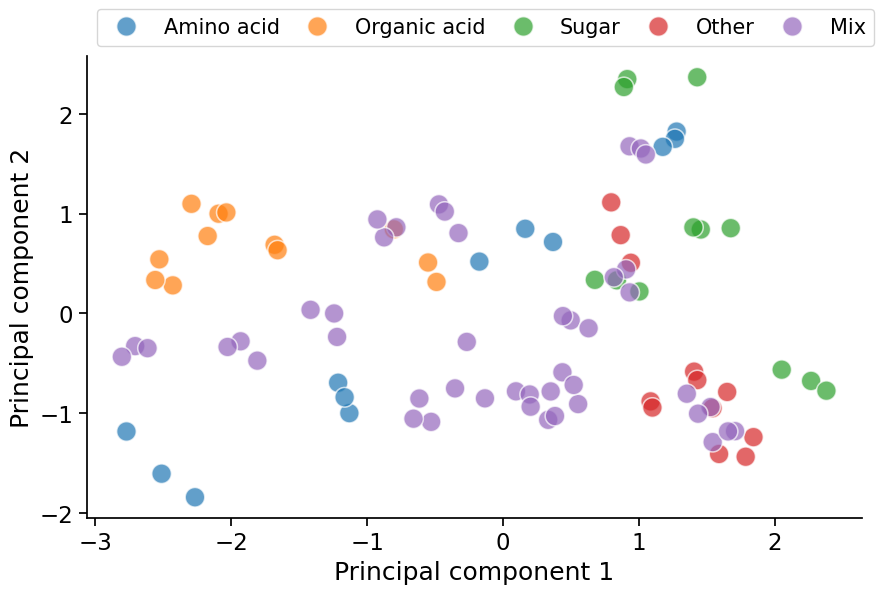

In [180]:
fig, ax = plt.subplots(figsize=(10,6))

g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'Carbon source class', s = 200, alpha = 0.7, 
                    hue_order=['Amino acid', 'Organic acid', 'Sugar', 'Other', 'Mix'], palette = 'tab10')
sns.despine()
sns.move_legend(g, loc = 'lower left', bbox_to_anchor = (0,1), ncol=5,
                fontsize='small',  # Reduce the font size of legend labels
                title='',
    labelspacing=0.5,  # Reduce spacing between labels
    columnspacing=0.8)
# plt.tight_layout()
plt.savefig(figure_folder / 'pca_cs_class.pdf', bbox_inches='tight')

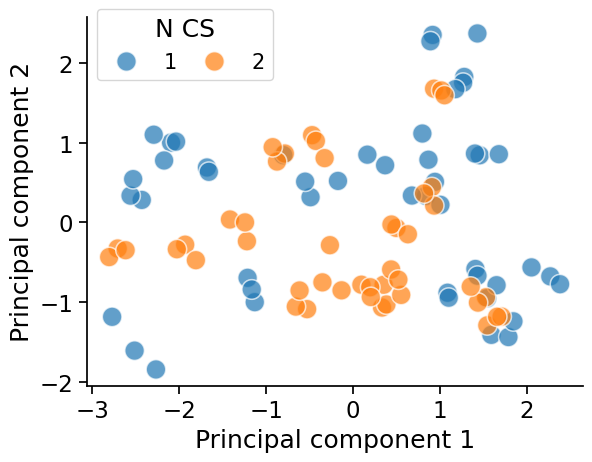

In [186]:

g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'N CS', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 'lower left', bbox_to_anchor = (0,0.8), ncol=4,
                fontsize='small',  # Reduce the font size of legend labels
                # title='',
    labelspacing=0.5,  # Reduce spacing between labels
    columnspacing=0.8
                )
# sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))
plt.savefig(figure_folder / 'PCA_n_cs.pdf')

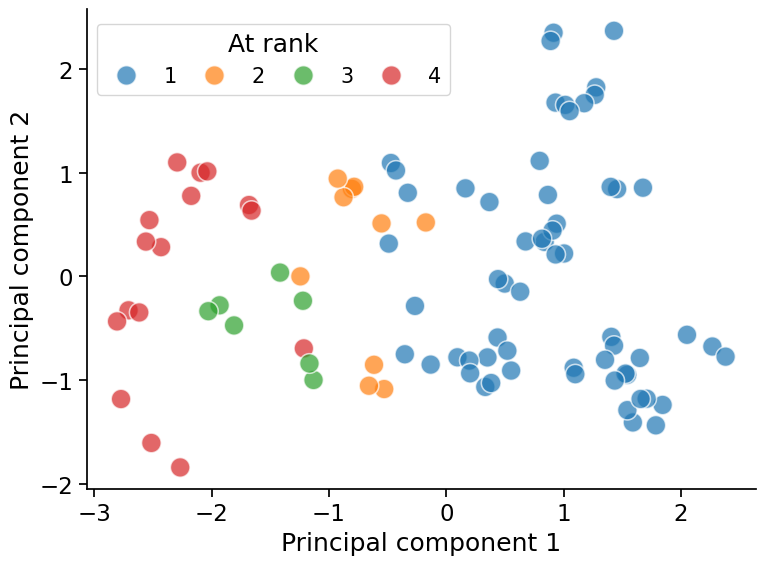

In [185]:
fig, ax = plt.subplots(figsize=(8, 6))
g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'At rank', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 'lower left', bbox_to_anchor = (0,0.8), ncol=4,
                fontsize='small',  # Reduce the font size of legend labels
                # title='',
    labelspacing=0.5,  # Reduce spacing between labels
    columnspacing=0.8
                )
plt.tight_layout()
plt.savefig(figure_folder / 'pca_growth_rate_rank_at.pdf')

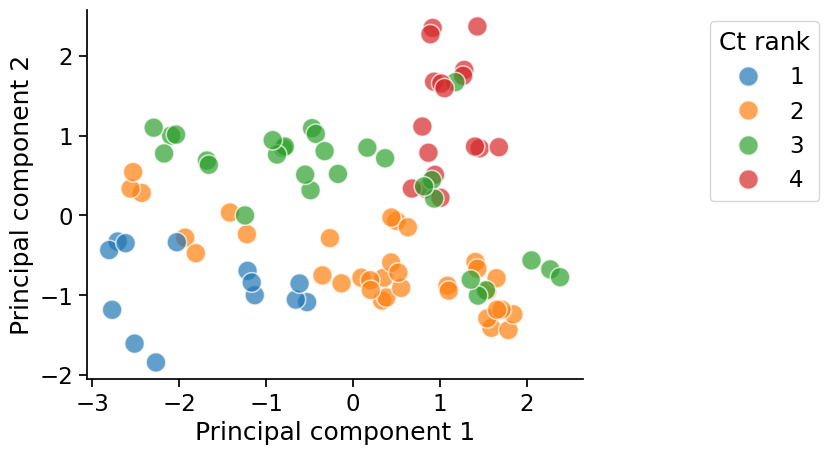

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'Ct rank', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))

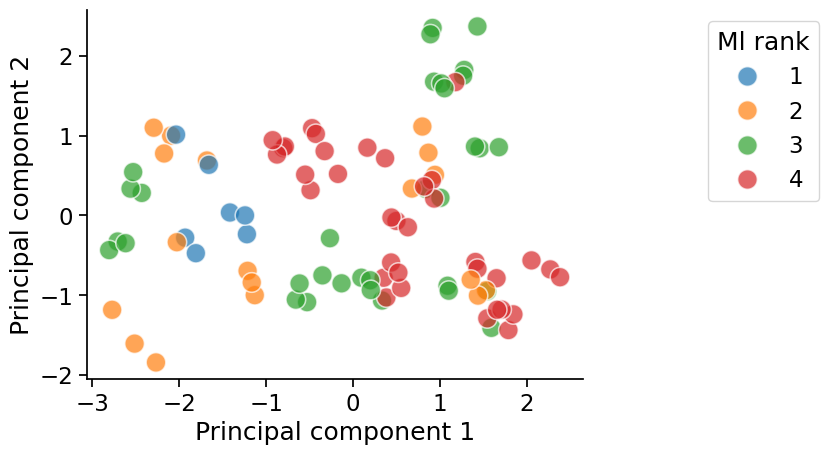

In [68]:

g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'Ml rank', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))

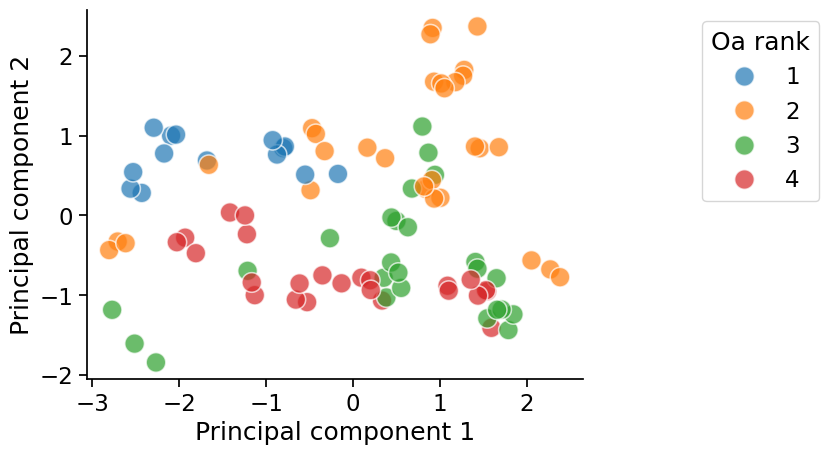

In [69]:

g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'Oa rank', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))

In [71]:
pca_df.to_csv(data_folder / 'pca.csv')

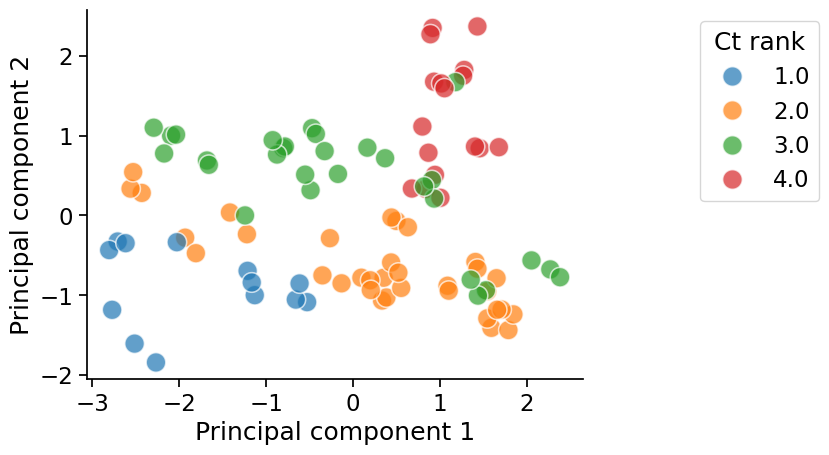

In [ ]:

g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'Ct rank', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))

# Correlations

In [93]:
cfu_data_all = df.pivot(index = ['Well', 'Batch'], columns = 'Strain', values = 'CFUs/mL')
cfu_data_all.drop(index=['H10', 'H11', 'H12'], inplace=True)
cfu_data_all.reset_index()
log_cfu_all = np.log10(cfu_data_all)


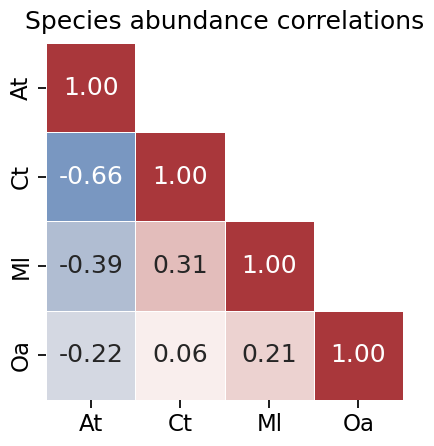

In [143]:
# Compute the correlation matrix
# Create a figure and gridspec to position the color bar
# fig, ax = plt.subplots(figsize=(6, 6))
# cbar_ax = fig.add_axes([0.6, 0.4, 0.02, 0.3])  # [left, bottom, width, height]

corr_matrix = log_cfu.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool),1)
sns.heatmap(corr_matrix, mask=mask, cmap='vlag', vmin = -1, vmax = 1, cbar = False, square=True, annot = True, 
            fmt = '.2f', linewidths=0.5, linecolor='white',
            # ax=ax, 
            # cbar_ax=cbar_ax, cbar_kws={'shrink':0.3, 'label': 'Correlation Coefficient', 'orientation': 'vertical'}
            )
plt.xlabel('')
plt.ylabel('')
ax=plt.gca()
# ax.set_xticks(ax.get_xticks()[:-1])  # Exclude the last tick
# ax.set_yticks(ax.get_yticks()[1:])  
# ax.set_xticklabels(ax.get_xticklabels())  # Exclude the last tick label
plt.title('Species abundance correlations', pad = 10)
plt.tight_layout()
plt.savefig(figure_folder / 'species_abundance_correlations.pdf', bbox_inches='tight')
plt.show()


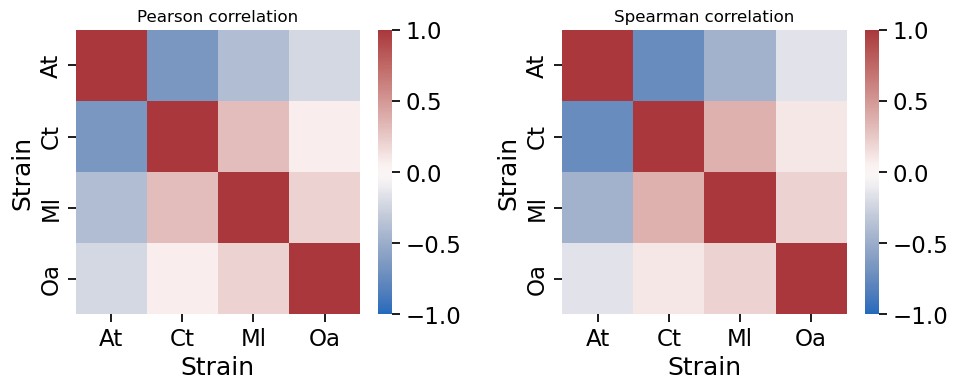

In [ ]:
fig, axes = plt.subplots(1,2, figsize = (10,4))
sns.heatmap(log_cfu.corr(), cmap='vlag', vmin = -1, vmax = 1, ax = axes[0], cbar = True, square=True,)
sns.heatmap(log_cfu.corr(method = 'spearman'), cmap='vlag', vmin = -1, vmax = 1, ax = axes[1], square=True)
axes[0].set_title('Pearson correlation', size = 12)
axes[1].set_title('Spearman correlation', size = 12)
plt.tight_layout()

In [ ]:
pca_mean = pca_df.groupby('Carbon source').mean(['Principal component 1',	'Principal component 2'])
pca_mean['N CS'] = [2 if '+' in x else 1 for x in pca_mean.index]

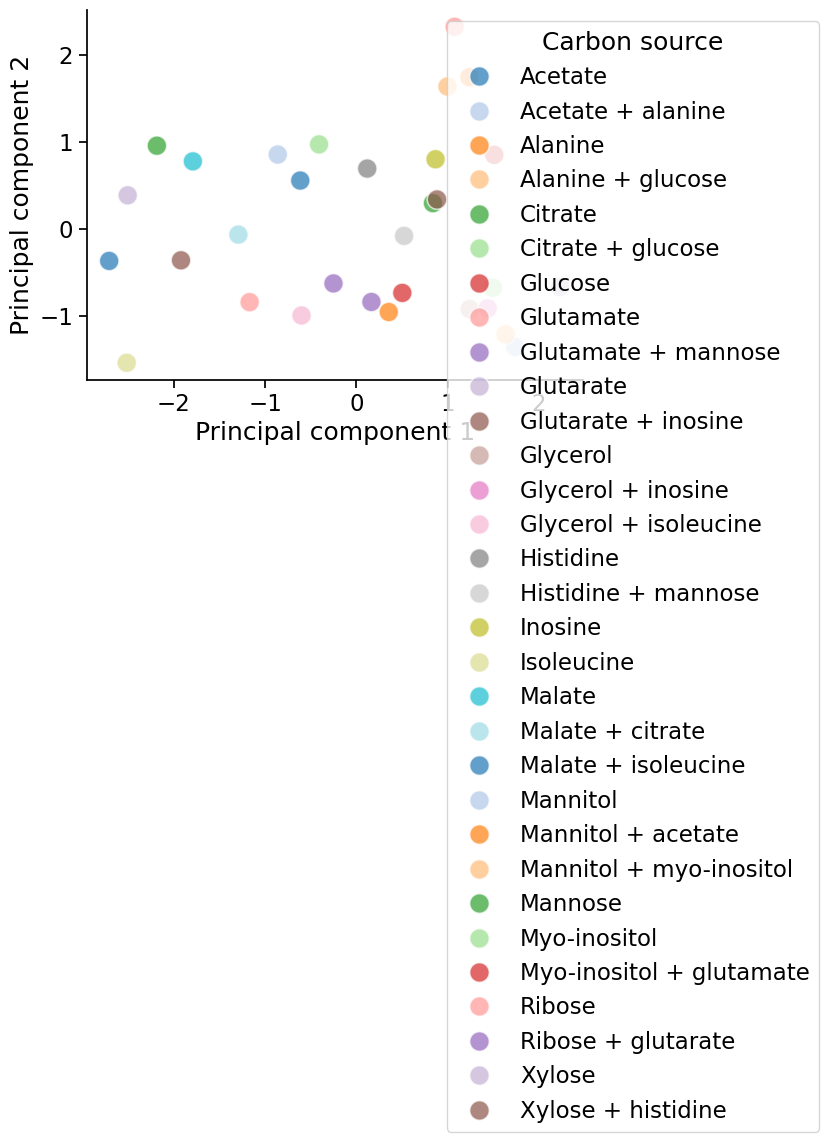

In [ ]:

g = sns.scatterplot(pca_mean, x = 'Principal component 1', y = 'Principal component 2', hue = 'Carbon source', s = 200, alpha = 0.7, 
                    palette = 'tab20'
                    )
sns.despine()
sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))

In [ ]:
well_to_cs_class

{'A1': 'Acetate',
 'A2': 'Acetate',
 'A3': 'Acetate',
 'A4': 'Glucose',
 'A5': 'Glucose',
 'A6': 'Glucose',
 'A7': 'Citrate',
 'A8': 'Citrate',
 'A9': 'Citrate',
 'A10': 'Glutarate',
 'A11': 'Glutarate',
 'A12': 'Glutarate',
 'B1': 'Glycerol',
 'B2': 'Glycerol',
 'B3': 'Glycerol',
 'B4': 'Inosine',
 'B5': 'Inosine',
 'B6': 'Inosine',
 'B7': 'Alanine',
 'B8': 'Alanine',
 'B9': 'Alanine',
 'B10': 'Glutamate',
 'B11': 'Glutamate',
 'B12': 'Glutamate',
 'C1': 'Histidine',
 'C2': 'Histidine',
 'C3': 'Histidine',
 'C4': 'Isoleucine',
 'C5': 'Isoleucine',
 'C6': 'Isoleucine',
 'C7': 'Malate',
 'C8': 'Malate',
 'C9': 'Malate',
 'C10': 'Mannitol',
 'C11': 'Mannitol',
 'C12': 'Mannitol',
 'D1': 'Mannose',
 'D2': 'Mannose',
 'D3': 'Mannose',
 'D4': 'Myo-inositol',
 'D5': 'Myo-inositol',
 'D6': 'Myo-inositol',
 'D7': 'Xylose',
 'D8': 'Xylose',
 'D9': 'Xylose',
 'D10': 'Ribose',
 'D11': 'Ribose',
 'D12': 'Ribose',
 'E1': 'Citrate + glucose',
 'E2': 'Citrate + glucose',
 'E3': 'Citrate + glucose',
 

Index(['Well', 'Batch', 'CFUs/mL', 'Strain', 'Carbon source', 'Replicate'], dtype='object')

In [ ]:
df_mean78

In [ ]:
sns.displot(data = df_mean78, x = 'Abundance rank', col = 'Strain', palette = palette)

ValueError: Could not interpret value `Strain` for `col`. An entry with this name does not appear in `data`.

In [ ]:

# Sort the DataFrame for better readability (optional)
df_sorted = df_mean78.sort_values(by=['Carbon source', 'Abundance Rank'])

# Display the result
print(df_sorted)